In [13]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [14]:
Income = pd.read_csv(r'E:\Amit Repository\Amit\python-for-ml\In_Session_Codes\Datasets\income.csv')

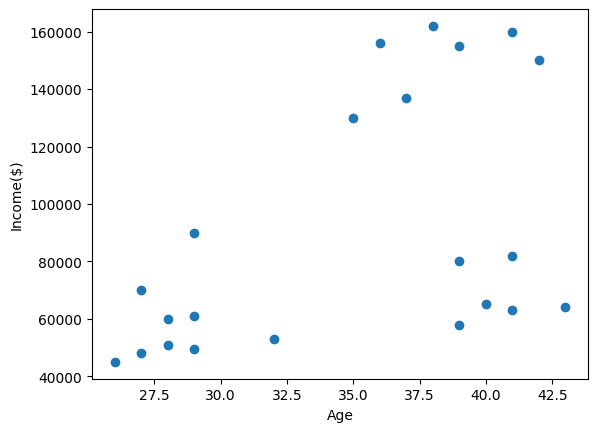

In [15]:
plt.scatter(Income['Age'], Income['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.show()

In [16]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(Income[['Age', 'Income($)']])
y_predicted

array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [17]:
Income['cluster'] = y_predicted
Income.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


In [18]:
km.cluster_centers_

array([[3.63333333e+01, 8.40000000e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04]])

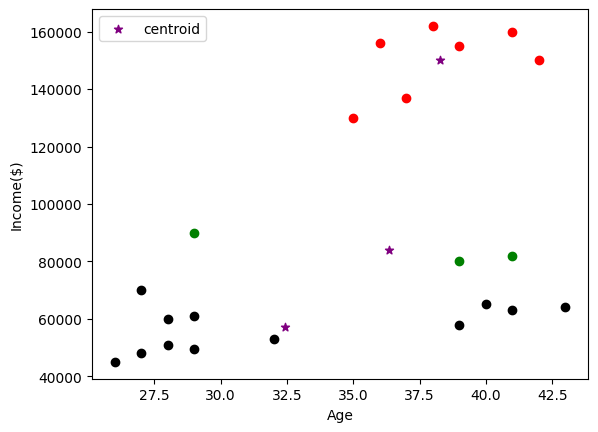

In [19]:
Income1 = Income[Income.cluster == 0]
Income2 = Income[Income.cluster == 1]
Income3 = Income[Income.cluster == 2]

plt.scatter(Income1['Age'], Income1['Income($)'], color='green')
plt.scatter(Income2['Age'], Income2['Income($)'], color='red')
plt.scatter(Income3['Age'], Income3['Income($)'], color='black')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='purple', marker='*', label='centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [20]:
scaler = MinMaxScaler()
scaler.fit(Income[['Income($)']])
Income['Income($)'] = scaler.transform(Income[['Income($)']])
Income.head()

,Name,Age,Income($),cluster
0,Rob,27,0.213675,2
1,Michael,29,0.384615,0
2,Mohan,29,0.136752,2
3,Ismail,28,0.128205,2
4,Kory,42,0.897436,1


In [21]:
Income['Age'] = scaler.fit_transform(Income[['Age']])
Income.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1


In [22]:
km1 = KMeans(n_clusters=3)
y_pred1 = km1.fit_predict(Income[['Age', 'Income($)']])
y_pred1

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [23]:
Income['cluster_2'] = y_pred1

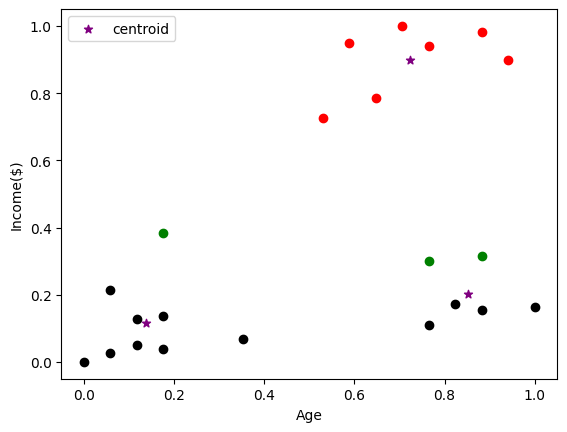

In [25]:
Income1 = Income[Income.cluster == 0]
Income2 = Income[Income.cluster == 1]
Income3 = Income[Income.cluster == 2]

plt.scatter(Income1['Age'], Income1['Income($)'], color='green')
plt.scatter(Income2['Age'], Income2['Income($)'], color='red')
plt.scatter(Income3['Age'], Income3['Income($)'], color='black')
plt.scatter(km1.cluster_centers_[:, 0], km1.cluster_centers_[:, 1], color='purple', marker='*', label='centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [26]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(Income[['Age', 'Income($)']])
    sse.append(km.inertia_)

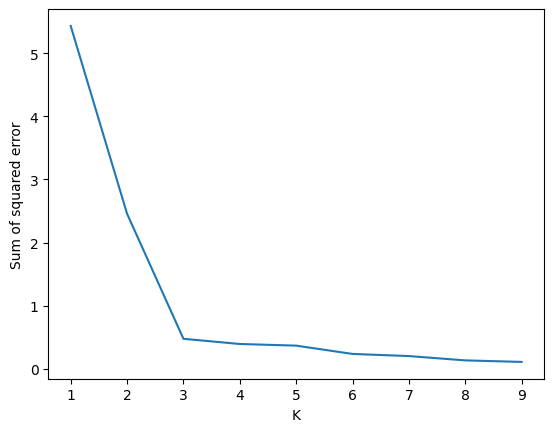

In [28]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)
plt.show()